[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed


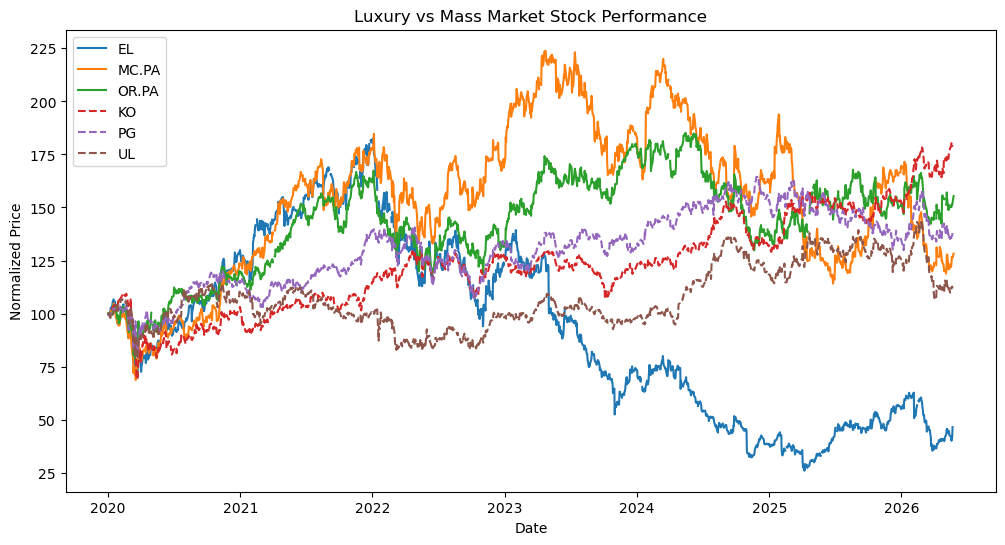

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Luxury companies
luxury = ['OR.PA', 'EL', 'MC.PA']

# FMCG companies
mass_market = ['UL', 'PG', 'KO']

# Download stock data
luxury_data = yf.download(luxury, start='2020-01-01')['Close']
mass_data = yf.download(mass_market, start='2020-01-01')['Close']

# Normalize prices
luxury_normalized = luxury_data / luxury_data.iloc[0] * 100
mass_normalized = mass_data / mass_data.iloc[0] * 100

# Plot
plt.figure(figsize=(12,6))

for col in luxury_normalized.columns:
    plt.plot(luxury_normalized[col], label=col)

for col in mass_normalized.columns:
    plt.plot(mass_normalized[col], linestyle='--', label=col)

plt.title('Luxury vs Mass Market Stock Performance')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.savefig('Luxury_data.png')
plt.show()


In [4]:
pip install fredapi

C:\Users\hp\AppData\Local\Temp\ipykernel_15444\3495164691.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi['Inflation_Rate'] = cpi['CPI'].pct_change(12) * 100


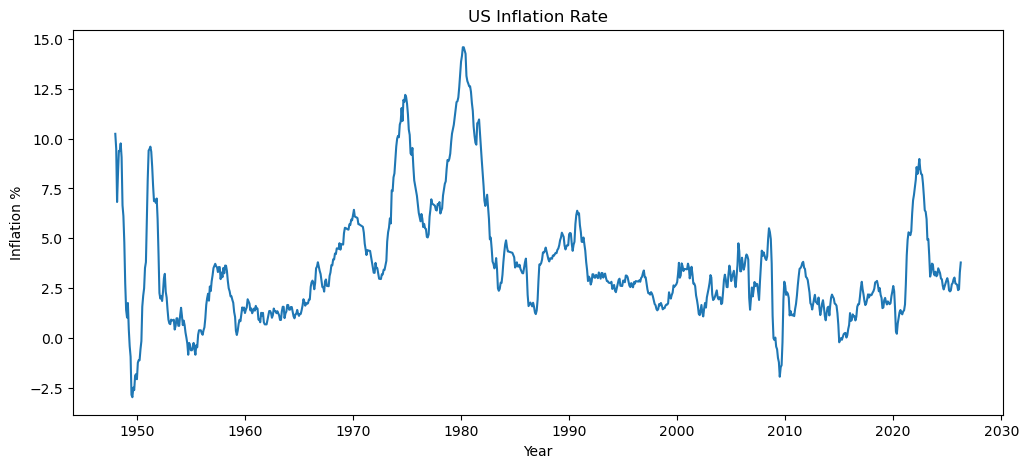

In [17]:
from fredapi import Fred

# Add your FRED API key here
fred = Fred(api_key='7531a04c3292f724910071ba54003922')

# Get CPI data
cpi = fred.get_series('CPIAUCSL')

# Convert to dataframe
cpi = pd.DataFrame(cpi, columns=['CPI'])

# Calculate inflation rate
cpi['Inflation_Rate'] = cpi['CPI'].pct_change(12) * 100

# Plot inflation
plt.figure(figsize=(12,5))
plt.plot(cpi.index, cpi['Inflation_Rate'])

plt.title('US Inflation Rate')
plt.xlabel('Year')
plt.ylabel('Inflation %')
plt.savefig('Inflation_data.png')
plt.show()

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed


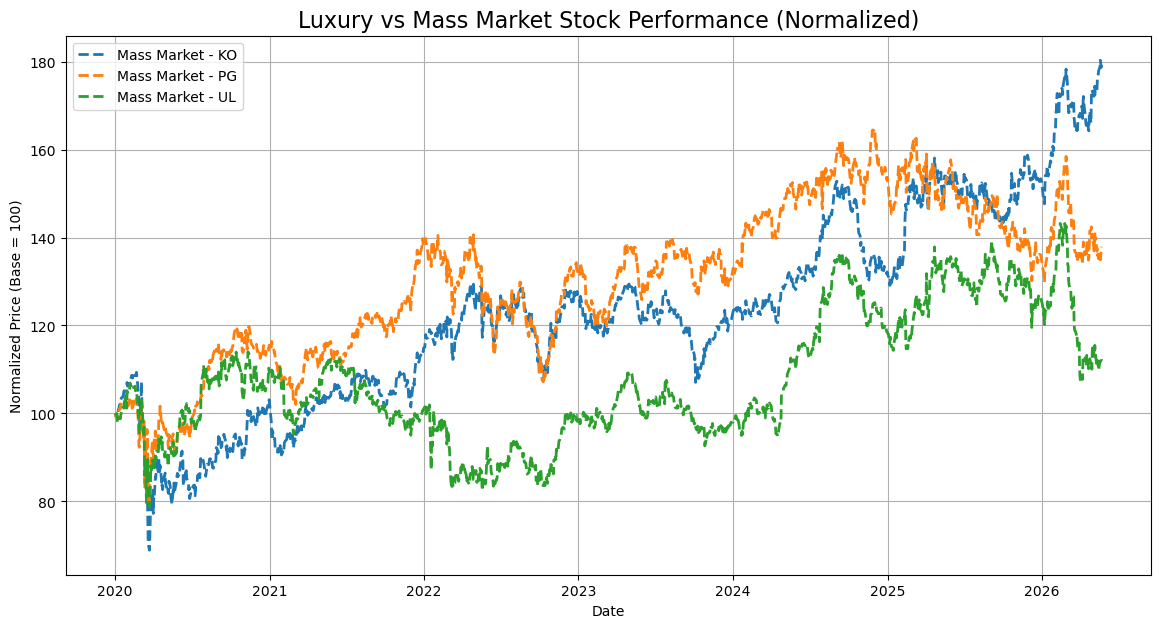

In [15]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Luxury companies
luxury = ['OR.PA', 'EL', 'MC.PA']

# FMCG companies
mass_market = ['UL', 'PG', 'KO']

# Download stock data
luxury_data = yf.download(luxury, start='2020-01-01')['Close']
mass_data = yf.download(mass_market, start='2020-01-01')['Close']
plt.figure(figsize=(14,7))


for col in mass_normalized.columns:
    plt.plot(mass_normalized[col],
             linestyle='--',
             linewidth=2,
             label=f'Mass Market - {col}')

plt.title('Luxury vs Mass Market Stock Performance (Normalized)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Normalized Price (Base = 100)')
plt.legend()
plt.grid(True)
plt.savefig('Structured_normalised_performance.png')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_15444\3451890037.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = luxury_data.pct_change().dropna()


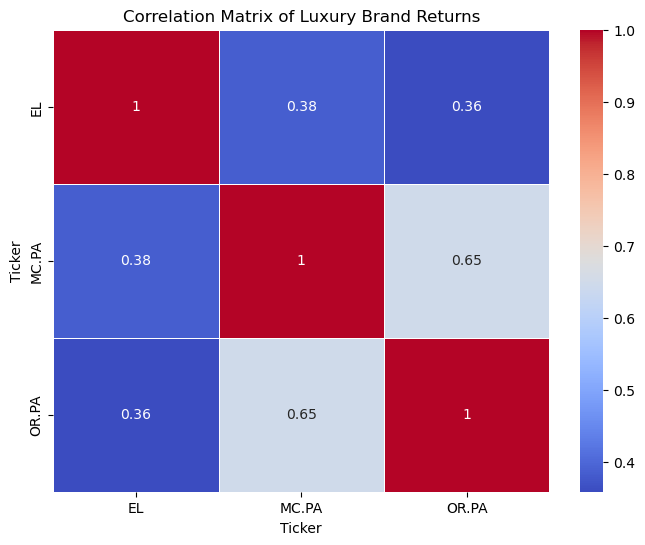

C:\Users\hp\AppData\Local\Temp\ipykernel_15444\3451890037.py:23: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = luxury_data.pct_change().dropna()


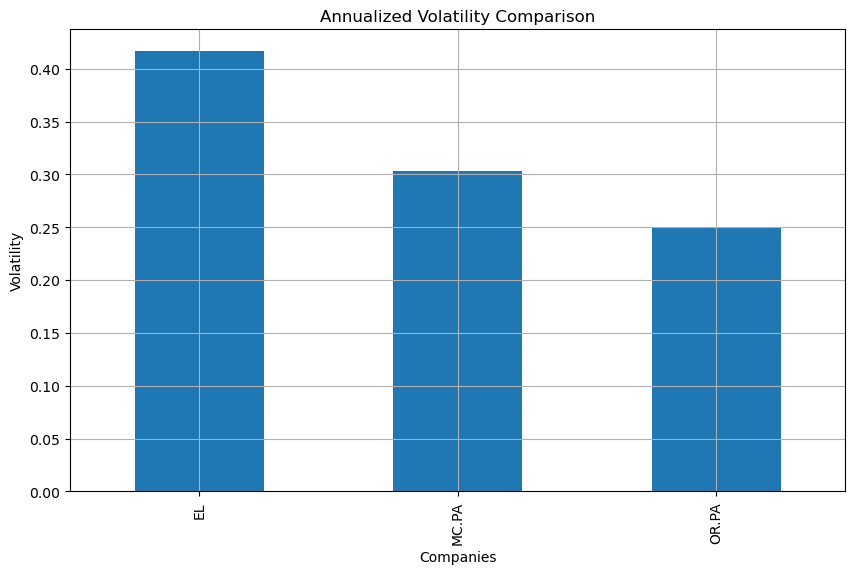

In [24]:
import seaborn as sns

# Daily returns
returns = luxury_data.pct_change().dropna()

# Correlation matrix
correlation_matrix = returns.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Matrix of Luxury Brand Returns')


plt.savefig('Correlation_Lux.png')
plt.show()
# Calculate daily returns
returns = luxury_data.pct_change().dropna()

# Annualized volatility
volatility = returns.std() * (252 ** 0.5)

# Convert to dataframe
volatility_df = volatility.sort_values(ascending=False)

# Plot volatility comparison
plt.figure(figsize=(10,6))

volatility_df.plot(kind='bar')

plt.title('Annualized Volatility Comparison')
plt.xlabel('Companies')
plt.ylabel('Volatility')

plt.grid(True)
plt.savefig('Volatility_Comp.png')
plt.show()